In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load best models
rf_fraud = joblib.load('../models/rf_fraud.pkl')
xgb_cc = joblib.load('../models/xgb_cc.pkl')

# Load test data
X_test_f = pd.read_csv('../data/processed/X_test_fraud.csv')
y_test_f = pd.read_csv('../data/processed/y_test_fraud.csv').squeeze()

X_test_cc = pd.read_csv('../data/processed/X_test_cc.csv')
y_test_cc = pd.read_csv('../data/processed/y_test_cc.csv').squeeze()

print("Models and data loaded!")

Models and data loaded!


In [2]:
# Use a sample for speed
X_sample_f = X_test_f.sample(500, random_state=42)

explainer_f = shap.TreeExplainer(rf_fraud)
shap_values_f = explainer_f.shap_values(X_sample_f)

# For binary classification, shap_values is a list — take class 1 (fraud)
shap_fraud = shap_values_f[:, :, 1] if len(np.array(shap_values_f).shape) == 3 else shap_values_f[1]

print("SHAP values computed for Fraud Data!")
print("Shape:", np.array(shap_fraud).shape)

SHAP values computed for Fraud Data!
Shape: (500, 194)


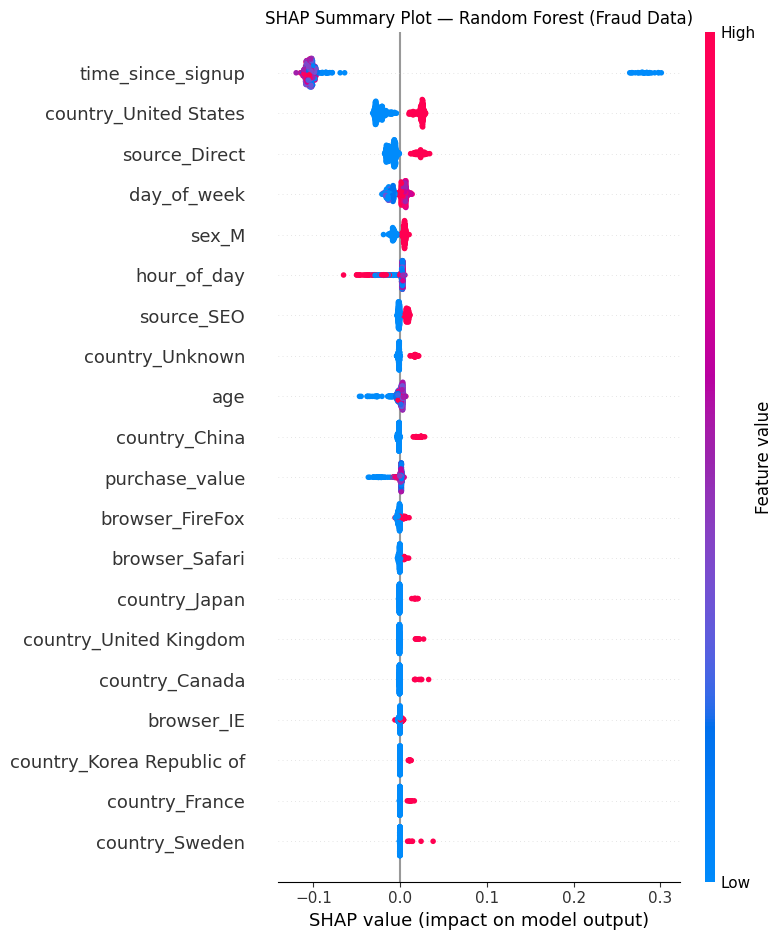

Summary plot saved!


In [3]:
plt.figure()
shap.summary_plot(shap_fraud, X_sample_f, show=False)
plt.title("SHAP Summary Plot — Random Forest (Fraud Data)")
plt.tight_layout()
plt.savefig('../data/processed/shap_summary_fraud.png', bbox_inches='tight')
plt.show()
print("Summary plot saved!")

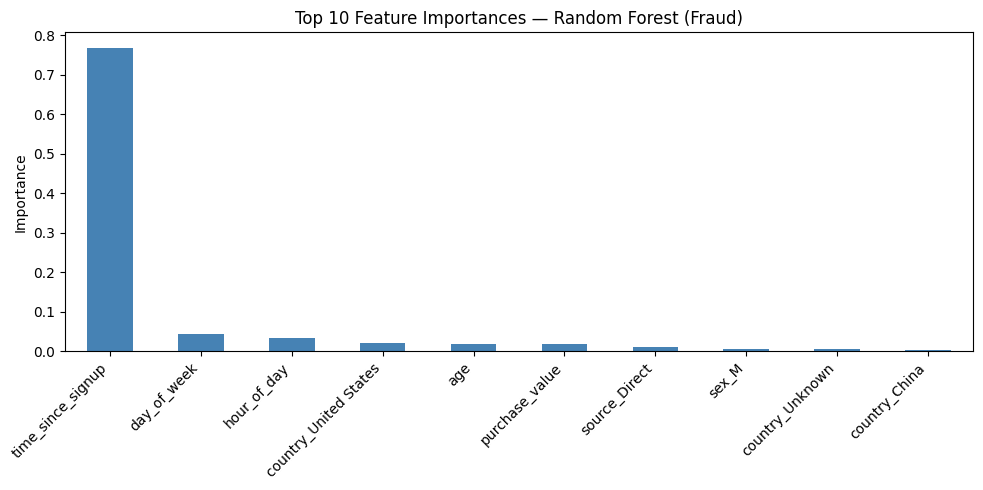

In [4]:
feat_imp = pd.Series(rf_fraud.feature_importances_, index=X_test_f.columns)
feat_imp = feat_imp.sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Top 10 Feature Importances — Random Forest (Fraud)')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/feature_importance_fraud.png')
plt.show()

In [5]:
# Use the full test set instead of sample for finding examples
y_pred_full = rf_fraud.predict(X_test_f)
y_full = y_test_f.values

# True Positive — actual fraud, predicted fraud
tp_mask = (y_full == 1) & (y_pred_full == 1)
fp_mask = (y_full == 0) & (y_pred_full == 1)
fn_mask = (y_full == 1) & (y_pred_full == 0)

print("True Positives found:", tp_mask.sum())
print("False Positives found:", fp_mask.sum())
print("False Negatives found:", fn_mask.sum())

tp_pos = np.where(tp_mask)[0][0]
fp_pos = np.where(fp_mask)[0][0]
fn_pos = np.where(fn_mask)[0][0]

print("\nPositions — TP:", tp_pos, "| FP:", fp_pos, "| FN:", fn_pos)

True Positives found: 1484
False Positives found: 35
False Negatives found: 1346

Positions — TP: 17 | FP: 310 | FN: 2


=== TRUE POSITIVE (Correctly Identified Fraud) ===


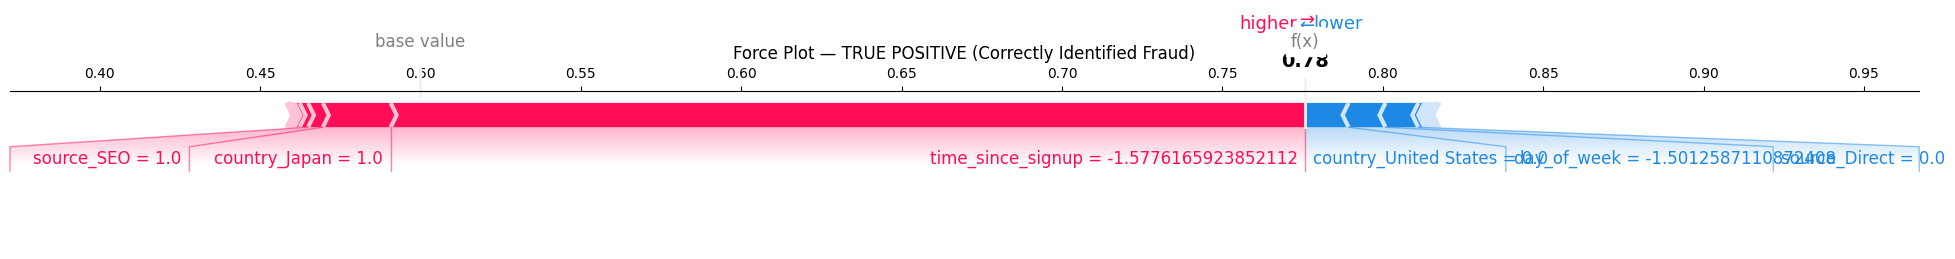

=== FALSE POSITIVE (Legit flagged as Fraud) ===


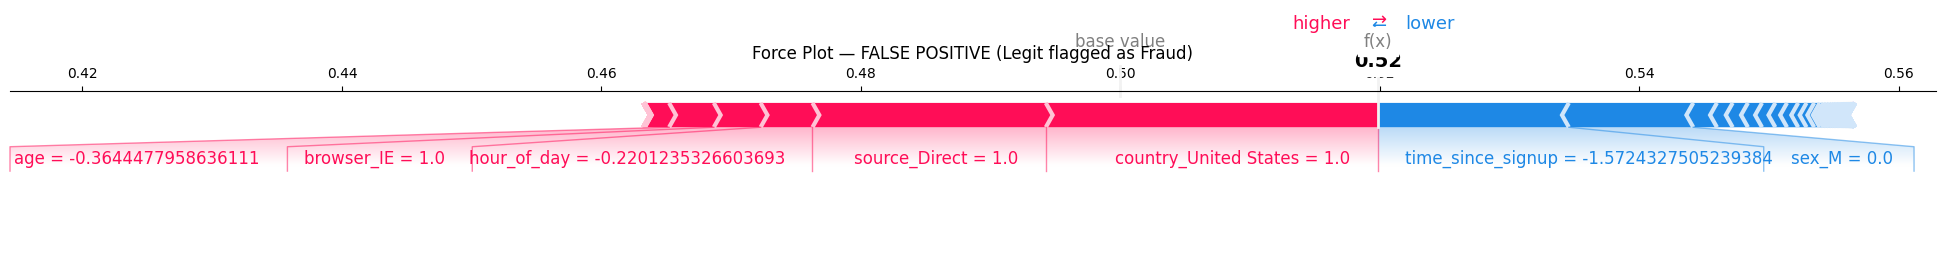

=== FALSE NEGATIVE (Missed Fraud) ===


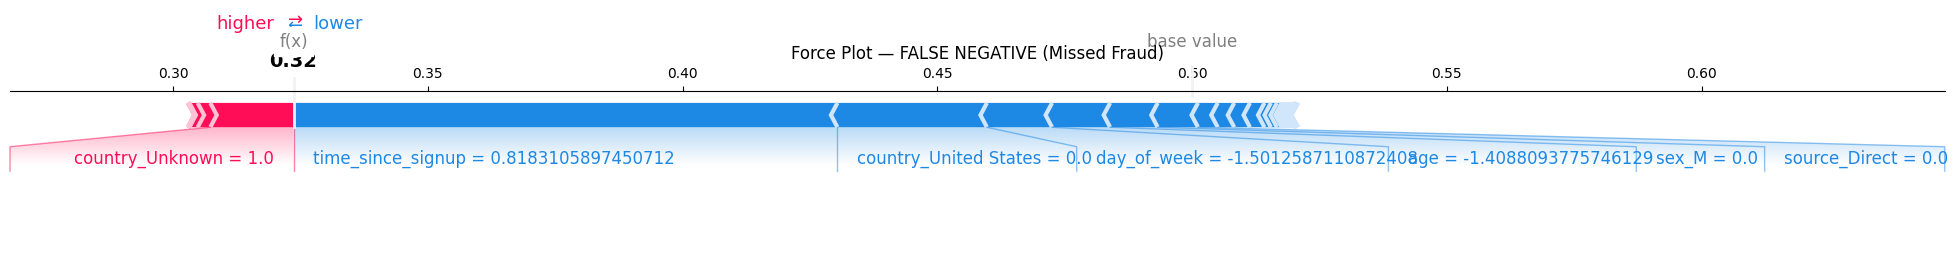

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

# Ensure required objects exist when the cell is run alone after a kernel reset
if 'rf_fraud' not in globals():
    rf_fraud = joblib.load('../models/rf_fraud.pkl')
if 'X_test_f' not in globals():
    X_test_f = pd.read_csv('../data/processed/X_test_fraud.csv')
if 'y_test_f' not in globals():
    y_test_f = pd.read_csv('../data/processed/y_test_fraud.csv').squeeze()
if 'tp_pos' not in globals() or 'fp_pos' not in globals() or 'fn_pos' not in globals():
    y_pred_full = rf_fraud.predict(X_test_f)
    y_full = y_test_f.values
    tp_mask = (y_full == 1) & (y_pred_full == 1)
    fp_mask = (y_full == 0) & (y_pred_full == 1)
    fn_mask = (y_full == 1) & (y_pred_full == 0)
    tp_pos = np.where(tp_mask)[0][0]
    fp_pos = np.where(fp_mask)[0][0]
    fn_pos = np.where(fn_mask)[0][0]

shap.initjs()

# Compute SHAP on full test set
explainer_f2 = shap.TreeExplainer(rf_fraud)
shap_values_full = explainer_f2.shap_values(X_test_f)
# Normalize to a (n_samples, n_features) array for class 1 when possible
if isinstance(shap_values_full, list):
    shap_vals_class1 = shap_values_full[1]
elif isinstance(np.array(shap_values_full), np.ndarray) and np.array(shap_values_full).ndim == 3:
    shap_vals_class1 = np.array(shap_values_full)[:, :, 1]
else:
    shap_vals_class1 = np.array(shap_values_full)

base_val = explainer_f2.expected_value
# extract scalar base value for class 1 if needed
if isinstance(base_val, (list, tuple, np.ndarray)):
    try:
        base_val_class1 = base_val[1]
    except Exception:
        base_val_class1 = base_val
else:
    base_val_class1 = base_val

def _save_force(idx, title, outpath):
    print(f"=== {title} ===")
    sv = shap_vals_class1[idx]
    feat = X_test_f.iloc[idx]
    shap.force_plot(base_val_class1, sv, feat, matplotlib=True, show=False)
    plt.title(f"Force Plot — {title}")
    plt.tight_layout()
    plt.savefig(outpath, bbox_inches='tight')
    plt.show()

# True Positive
_save_force(tp_pos, "TRUE POSITIVE (Correctly Identified Fraud)", '../data/processed/force_plot_tp.png')

# False Positive
_save_force(fp_pos, "FALSE POSITIVE (Legit flagged as Fraud)", '../data/processed/force_plot_fp.png')

# False Negative
_save_force(fn_pos, "FALSE NEGATIVE (Missed Fraud)", '../data/processed/force_plot_fn.png')